# Principal Component Analysis (PCA): A Comprehensive Guide

PCA is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional form while preserving as much variance (information) as possible. It finds the axes (principal components) along which data varies the most.

In this notebook, we'll cover:
1. Basic concepts of PCA
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for PCA
5. Applications and evaluation

# Simple Explanation: What Does the Code Below Do?

Imagine you have a 3D object (like a vase) and you want to photograph it. Taking a photograph squashes it from 3D to 2D. PCA is like choosing the BEST camera angle that captures the most detail in 2D.

PCA finds the directions in the data where it spreads out the most:
- **PC1 (First Principal Component)**: Direction of maximum variance.
- **PC2**: Direction of second maximum variance, perpendicular to PC1.
- ... and so on.

We can then keep only the top K components, effectively compressing the data.

Key uses:
- **Visualization**: Compress to 2D/3D to plot high-dimensional data.
- **Noise Reduction**: Remove low-variance dimensions (often noise).
- **Speed**: Fewer features → faster training of other models.

Here's what the code does:
1. Implements PCA from scratch using eigendecomposition.
2. Uses sklearn PCA on the Iris and digits datasets.
3. Shows how to choose the number of components using explained variance.

In short: PCA finds the most informative 'viewpoints' of your data!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use the Iris dataset (4D → 2D) and show how PCA visualizes it.

Original shape: (150, 4) (4 features)


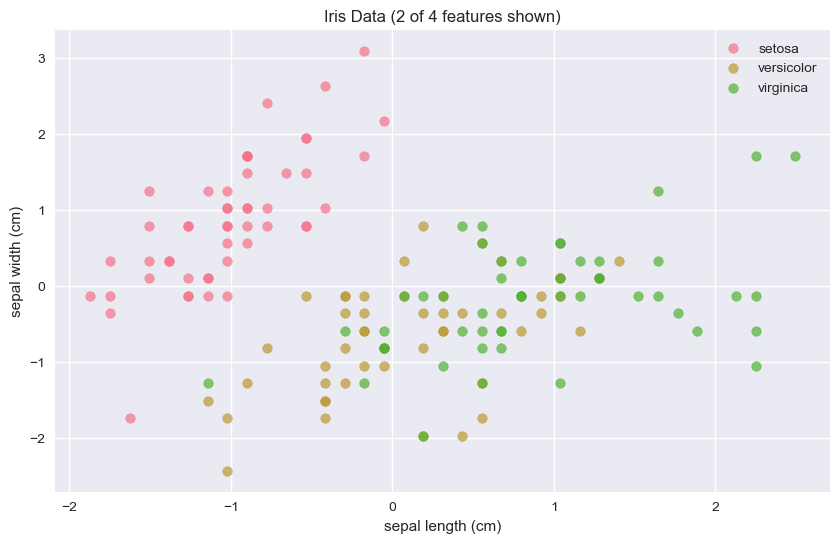

In [3]:
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names
feature_names = iris.feature_names

print(f'Original shape: {X.shape} ({X.shape[1]} features)')

# Scale data (crucial for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pairplot to visualize all 4 features
df = pd.DataFrame(X_scaled, columns=feature_names)
df['species'] = [class_names[i] for i in y]

plt.figure(figsize=(10, 6))
for i, cls in enumerate(class_names):
    subset = df[df['species'] == cls]
    plt.scatter(subset[feature_names[0]], subset[feature_names[1]], label=cls, alpha=0.7)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Iris Data (2 of 4 features shown)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing PCA from Scratch

PCA uses eigendecomposition of the covariance matrix:
1. Center the data (subtract mean).
2. Compute the covariance matrix.
3. Find eigenvectors and eigenvalues of the covariance matrix.
4. Sort by eigenvalue (larger = more variance).
5. Project data onto top K eigenvectors.

Reduced shape: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Total variance retained: 0.9581 (95.8%)


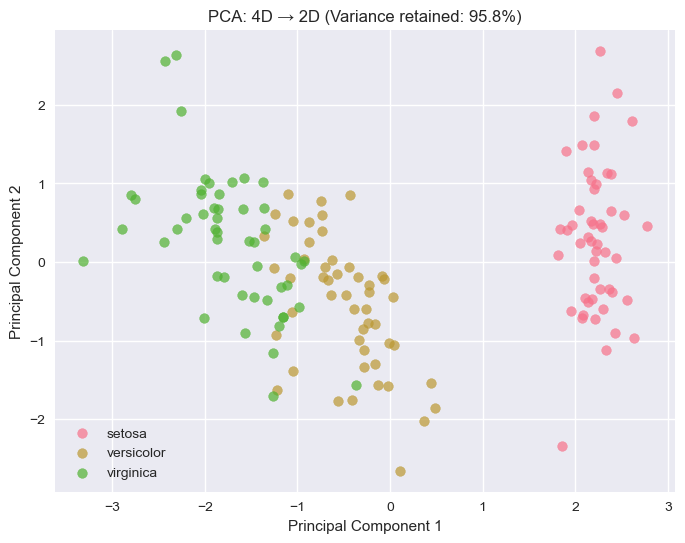

In [4]:
class PCAScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        # Center the data
        self.mean = X.mean(axis=0)
        X_centered = X - self.mean

        # Covariance matrix
        cov_matrix = np.cov(X_centered.T)

        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort by eigenvalue (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Keep top n_components
        self.components = eigenvectors[:, :self.n_components]
        total_variance = eigenvalues.sum()
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_variance
        return self

    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        return self.fit(X).transform(X)

# Apply PCA (4D → 2D)
pca_scratch = PCAScratch(n_components=2)
X_pca = pca_scratch.fit_transform(X_scaled)

print(f'Reduced shape: {X_pca.shape}')
print(f'Explained variance ratio: {pca_scratch.explained_variance_ratio_}')
print(f'Total variance retained: {pca_scratch.explained_variance_ratio_.sum():.4f} ({pca_scratch.explained_variance_ratio_.sum()*100:.1f}%)')

# Visualize 2D projection
plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'PCA: 4D → 2D (Variance retained: {pca_scratch.explained_variance_ratio_.sum()*100:.1f}%)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Using Scikit-learn's PCA

Let's apply PCA to a higher-dimensional dataset (Digits: 64 features → 2D) to show its power.

Digits dataset shape: (1797, 64)
Reduced shape: (1797, 2)
Variance explained: 0.2159

Components to retain 95% variance: 40 (from 64)


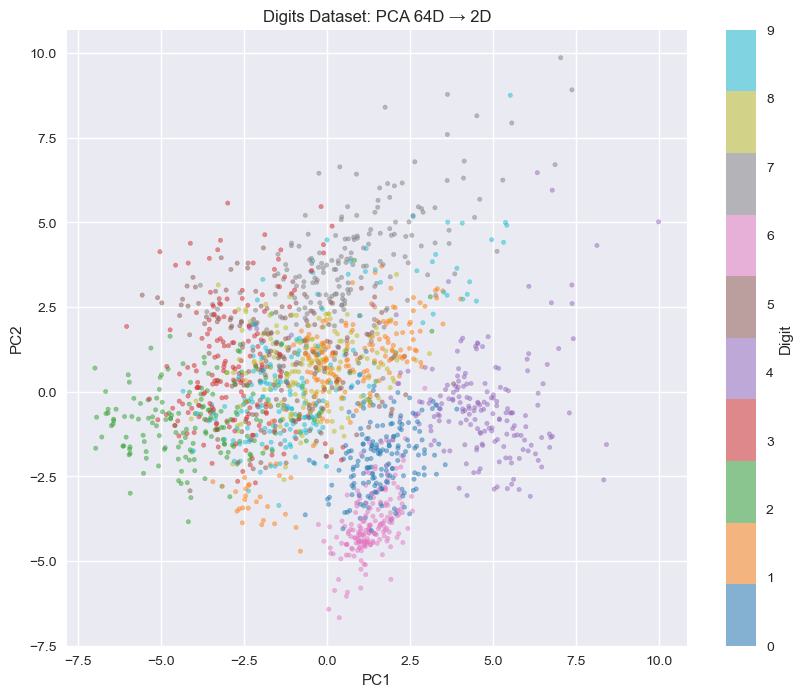

In [5]:
# Load digits dataset (64 features)
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print(f'Digits dataset shape: {X_digits.shape}')

# Scale
scaler_d = StandardScaler()
X_digits_scaled = scaler_d.fit_transform(X_digits)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_digits_scaled)

print(f'Reduced shape: {X_2d.shape}')
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.4f}')

# PCA to keep 95% variance
pca_95 = PCA(n_components=0.95, random_state=42)
X_95 = pca_95.fit_transform(X_digits_scaled)
print(f'\nComponents to retain 95% variance: {pca_95.n_components_} (from 64)')

# Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_digits, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Digit')
plt.title('Digits Dataset: PCA 64D → 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# 5. Model Evaluation — Choosing Number of Components

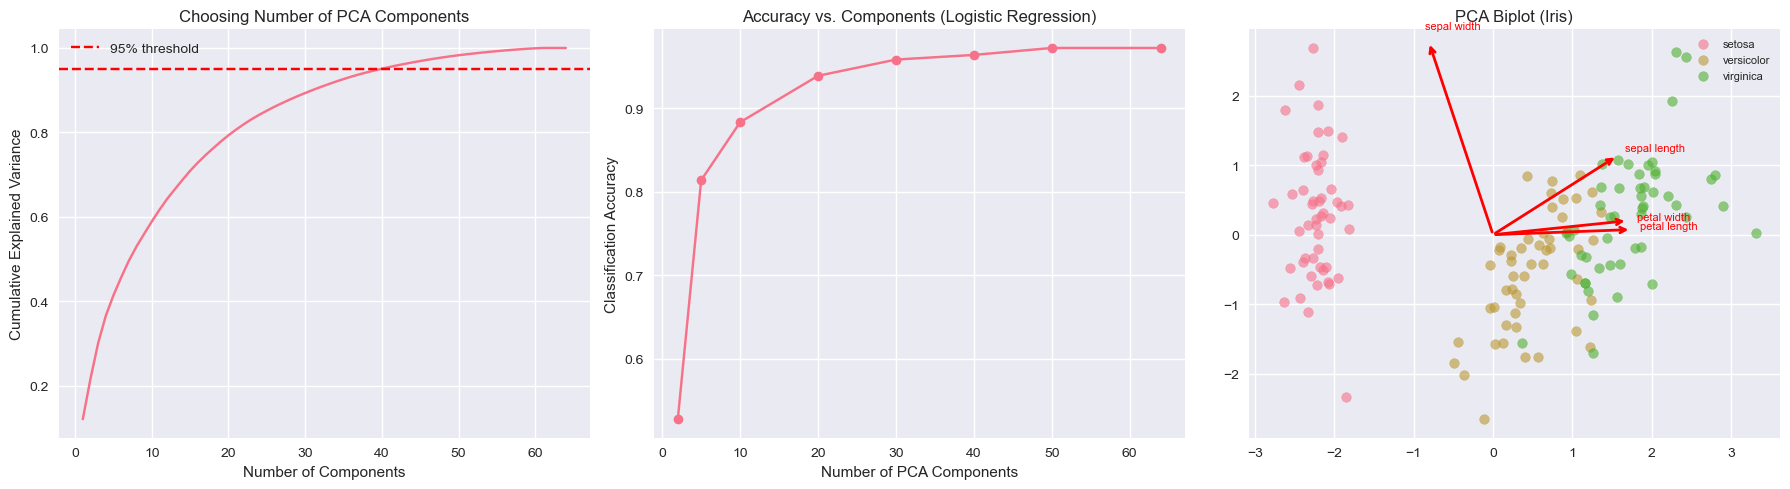


Key Insights:
- PCA reduces dimensionality while preserving variance.
- Use the "Explained Variance" plot to choose the right number of components.
- Always standardize data before PCA!
- Biplot arrows show how original features relate to principal components.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Explained Variance Plot
pca_full = PCA(random_state=42)
pca_full.fit(X_digits_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].plot(range(1, len(cumulative_var)+1), cumulative_var)
axes[0].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Choosing Number of PCA Components')
axes[0].legend()
axes[0].grid(True)

# 2. PCA for Classification Speed vs Accuracy
n_components_list = [2, 5, 10, 20, 30, 40, 50, 64]
X_train, X_test, y_train, y_test = train_test_split(X_digits_scaled, y_digits, test_size=0.2, random_state=42)

accs = []
for nc in n_components_list:
    if nc < X_digits_scaled.shape[1]:
        pca_n = PCA(n_components=nc)
        X_tr = pca_n.fit_transform(X_train)
        X_te = pca_n.transform(X_test)
    else:
        X_tr, X_te = X_train, X_test
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    accs.append(accuracy_score(y_test, clf.predict(X_te)))

axes[1].plot(n_components_list, accs, marker='o')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Classification Accuracy')
axes[1].set_title('Accuracy vs. Components (Logistic Regression)')
axes[1].grid(True)

# 3. Visualize PCA biplot (loadings)
pca2 = PCA(n_components=2)
X_iris_2d = pca2.fit_transform(X_scaled)
for i, cls in enumerate(class_names):
    mask = y == i
    axes[2].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1], label=cls, alpha=0.6)
# Add feature vectors
for j, fname in enumerate(feature_names):
    axes[2].annotate('', xy=(pca2.components_[0, j]*3, pca2.components_[1, j]*3), 
                     xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='red', lw=2))
    axes[2].text(pca2.components_[0, j]*3.2, pca2.components_[1, j]*3.2, 
                 fname.replace(' (cm)', ''), fontsize=8, color='red')
axes[2].set_title('PCA Biplot (Iris)')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- PCA reduces dimensionality while preserving variance.')
print('- Use the "Explained Variance" plot to choose the right number of components.')
print('- Always standardize data before PCA!')
print('- Biplot arrows show how original features relate to principal components.')

# Conclusions and Key Takeaways
Principal Component Analysis (PCA) is an essential unsupervised dimensionality reduction technique. It transforms a large set of correlated variables into a much smaller set of entirely uncorrelated variables called Principal Components, while retaining as much original variance (information) as possible.
- **Variance Maximization**: The first principal component is a line in space that captures the absolute maximum amount of variance (spread) in the data.
- **Orthogonality**: Every subsequent principal component captures the maximum remaining variance while being completely mathematically orthogonal (at a 90-degree angle/uncorrelated) to the previous ones.
- **Preprocessing powerhouse**: Often used to strip multicollinearity out of datasets prior to feeding them into algorithms like Linear Regression or to visualize high-dimensional data in 2D or 3D.

# Pros and Cons
**Pros:**
- Completely removes multicollinearity (since all PCs are perfectly uncorrelated).
- Reduces the computational cost and memory footprint of training machine learning models.
- Excellent for noise reduction; dropping the lowest-variance components often drops the random noise out of the dataset.

**Cons:**
- Principal Components are linear combinations of original features, severely destroying the interpretability of the model. (You can't explain to a boss why "PC_1" caused a loan denial).
- It is strictly a linear algorithm. It cannot capture non-linear manifold relationships in the data.
- It assumes that the directions with maximum variance are the most highly informative, which isn't always true for classification tasks.

# 15 Interview Questions and Answers

1. **What is Principal Component Analysis (PCA)?**
   *Answer*: An unsupervised statistical technique used to reduce the dimensionality of a dataset while preserving the maximum possible amount of variance (information) by creating new, uncorrelated variables.

2. **Why is data standardization absolutely mandatory before applying PCA?**
   *Answer*: PCA hunts for features with the highest variance. If variable A is measured in millimeters (range 1-1000) and variable B in kilometers (range 1-5), the algorithm will think variable A has vastly more variance purely because of its scale, ruining the component calculation.

3. **What is an Eigenvector and Eigenvalue in the context of PCA?**
   *Answer*: The Eigenvectors of the covariance matrix represent the *directions* (the axes) of the new Principal Components. The Eigenvalues represent the *magnitude* or amount of variance captured by that specific Eigenvector.

4. **Why are Principal Components strictly orthogonal?**
   *Answer*: By enforcing orthogonality (90-degree angles in multi-dimensional space), the math ensures that there is absolutely zero correlation (multicollinearity) between any two Principal Components.

5. **How do you decide how many Principal Components to keep?**
   *Answer*: By looking at the Cumulative Explained Variance curve. You select the number of components that accounts for a predefined threshold of acceptable variance, typically 80%, 90%, or 95%.

6. **What is the "Curse of Dimensionality" and how does PCA help?**
   *Answer*: The curse states that as the number of features increases, the feature space explodes exponentially, making the data incredibly sparse and causing algorithms to severely overfit or fail. PCA fixes this by compressing the data back down into a dense, dense low-dimensional space.

7. **Does PCA help prevent overfitting?**
   *Answer*: Yes, indirectly. By dropping the components with the lowest eigenvalues, you are almost always dropping random noise in the data, resulting in a simpler, regularized model that generalizes better.

8. **Is PCA a feature selection technique?**
   *Answer*: No, it is a feature *extraction* technique. Feature selection involves dropping original variables (keeping Age, dropping Income). PCA combines all variables together (PC1 = 0.5*Age + 0.2*Income), keeping elements of all features but losing interpretability.

9. **What happens to the interpretability of your model after applying PCA?**
   *Answer*: It is almost entirely destroyed. Your features are now abstract mathematical vectors (e.g., PC_1, PC_2) representing a mix of everything, making it impossible to answer "how did age affect the prediction?"

10. **Can PCA capture non-linear relationships?**
    *Answer*: Natively, no. Standard PCA relies on linear algebraic transformations. If the data resembles a rolled-up Swiss Roll, PCA will crush it. You must use Kernel PCA or algorithms like t-SNE or Autoencoders for non-linear reduction.

11. **What is Kernel PCA?**
    *Answer*: An extension of PCA that uses the kernel trick (similar to SVMs) to implicitly project data into a higher-dimensional space where non-linear patterns become linearly separable, allowing PCA to calculate non-linear principal components.

12. **What is the difference between PCA and Linear Discriminant Analysis (LDA)?**
    *Answer*: PCA is an Unsupervised algorithm that finds the axes of maximum variance, ignoring class labels entirely. LDA is a Supervised algorithm that explicitly finds axes that maximize the absolute separation between known classes.

13. **Why might PCA degrade the performance of a classification model?**
    *Answer*: PCA assumes that high variance equals high importance. Sometimes, the feature that perfectly separates two classes actually has very low variance. PCA will drop it, destroying the model's accuracy.

14. **How are the Principal Components ordered?**
    *Answer*: They are ordered descending by their Eigenvalues. The first PC contains the maximum possible variance, the second PC contains the second highest variance, and so on.

15. **What is t-SNE and when would you use it over PCA?**
    *Answer*: t-Distributed Stochastic Neighbor Embedding. It is vastly superior to PCA for *visualizing* distinct clusters of highly complex, non-linear high-dimensional data in 2D or 3D. However, t-SNE is too computationally expensive and erratic for use as a general feature preprocessing step for downstream machine learning models.
